# Reporte: Clasificación Binaria del Rol Ocupacional en el Mercado Laboral Mexicano

## 1. Introducción y Definición del Problema de Clasificación

En el análisis del mercado laboral mexicano, una pregunta frecuentemente ignorada es: ¿qué separa a quienes emplean de quienes son empleados? Más allá del nivel de ingresos, existen características sociodemográficas —edad, género, escolaridad— que podrían anticipar si una persona opera como patrón o como trabajador subordinado.

Este reporte aborda ese problema desde la perspectiva de la clasificación binaria: en lugar de predecir una cantidad continua, el modelo aprenderá a asignar cada individuo a una de dos categorías mutuamente excluyentes. Para ello, utilizamos datos de la Encuesta Nacional de Ocupación y Empleo (ENOE) del T3 2025 y empleamos regresión logística como modelo base, evaluado rigurosamente mediante validación cruzada.

### La Variable Objetivo: Empleador vs. Empleado

Utilizaremos la variable `pos_ocu` (Posición en la ocupación) de la ENOE para construir un escenario de clasificación binaria. Según la documentación oficial del INEGI (*Estructura de la base de datos, ENOE 2025*), los códigos válidos son:

| Código | Categoría INEGI |
|---|---|
| 1 | Trabajadores subordinados y remunerados (Empleado) |
| 2 | **Empleadores** |
| 3 | Trabajadores por cuenta propia |
| 4 | Trabajadores sin pago |
| 5 | No especificado |

> **Fuente:** INEGI. *Encuesta Nacional de Ocupación y Empleo (ENOE). Estructura de la base de datos. Segunda edición. 2025.* Campo 58: POS_OCU.

Nuestro escenario de clasificación binaria será:
- **Clase 1 (Positivo): Empleador** (`pos_ocu = 2`) — personas que emplean a otras.
- **Clase 0 (Negativo): Empleado subordinado** (`pos_ocu = 1`) — trabajadores asalariados.

Se excluyen los trabajadores por cuenta propia (`pos_ocu = 3`) porque su perfil es heterogéneo: abarca desde un *freelancer* digital hasta un limpiador ambulante de parabrisas, lo que generaría ambigüedad en la clasificación.

### Predictores Seleccionados

| Variable | Descripción | Tipo |
|---|---|---|
| `eda` | Edad del trabajador | Cuantitativa |
| `es_mujer` | Indicador de género (1 = Mujer) | Cualitativa |
| `anios_esc` | Años de escolaridad formal | Cuantitativa |
| `log_ingocup` | Logaritmo natural del ingreso mensual | Cuantitativa |

---

> **Nota metodológica sobre `log_ingocup`:**
Dado que hemos transformado el ingreso mensual a su logaritmo natural, este predictor tendrá una interpretación matemática especial (elástica) en la matriz de resultados, la cual se explicará a detalle en la Sección 6 dedicada a los coeficientes.

### Anticipación: Desbalance de Clases
En la economía mexicana real, la proporción de empleadores frente a empleados es drásticamente desigual — es razonable esperar que existan **muchos más empleados que empleadores**. Este desbalance natural es un reto clásico en Machine Learning y lo abordaremos explícitamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc,
                             classification_report)
import statsmodels.api as sm

# Configuraciones visuales
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
import warnings
warnings.filterwarnings("ignore")

## 1.1 Adquisición y Limpieza Inicial de Datos

Procesaremos la ENOE del T3 2025 aplicando los siguientes filtros de depuración:

In [2]:
df_raw = pd.read_csv("ENOE_SDEMT325.csv", encoding="latin1", low_memory=False)
columnas_interes = ["eda", "sex", "anios_esc", "ingocup", "pos_ocu"]
df = df_raw[columnas_interes].copy()

Depuración del ruido administrativo:
- Conversión de tipos (la ENOE puede contener valores codificados como texto).
- Filtro biológico: solo mayores de 18 años.
- Limpieza de códigos de error en educación (`99` = "No sabe").
- Rango de ingresos razonable ($500 – $900,000 MXN).

In [3]:
# Conversión a numérico
for col in ["eda", "anios_esc", "ingocup", "sex"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna()

# Filtros
df = df[df["eda"] >= 18]
df = df[(df["anios_esc"] != 99) & (df["anios_esc"] <= 30)]
df = df[(df["ingocup"] >= 500) & (df["ingocup"] <= 900000)]

## 1.2 Construcción de la Variable Cualitativa Binaria

Según la documentación oficial del INEGI, los códigos de `pos_ocu` son:
- **1:** Trabajadores subordinados y remunerados → **Clase 0 (Empleado)**
- **2:** Empleadores → **Clase 1 (Empleador)**
- **3:** Trabajadores por cuenta propia *(excluidos por ambigüedad)*
- **4:** Trabajadores sin pago *(excluidos)*

In [4]:
# Filtrar: 1 = Empleados subordinados, 2 = Empleadores
df_clasificacion = df[df["pos_ocu"].isin([1, 2])].copy()

# Variable binaria: 1 = Empleador, 0 = Empleado
df_clasificacion["es_empleador"] = np.where(df_clasificacion["pos_ocu"] == 2, 1, 0)

# Género: 1 = Mujer, 0 = Hombre
df_clasificacion["es_mujer"] = np.where(df_clasificacion["sex"] == 2, 1, 0)

# Logaritmo del ingreso
df_clasificacion["log_ingocup"] = np.log1p(df_clasificacion["ingocup"])

# Matriz final
datos_finales = df_clasificacion[["eda", "es_mujer", "anios_esc", "log_ingocup", "es_empleador"]].dropna()

print("Tamaño de la muestra de trabajo:", len(datos_finales))
conteo_clases = datos_finales["es_empleador"].value_counts(normalize=True) * 100
print("\nDistribución de Clases:")
print(f"  Empleados  (Clase 0): {conteo_clases[0]:.2f}%")
print(f"  Empleadores (Clase 1): {conteo_clases[1]:.2f}%")

Tamaño de la muestra de trabajo: 91242

Distribución de Clases:
  Empleados  (Clase 0): 93.03%
  Empleadores (Clase 1): 6.97%


### Análisis del Desbalance de Clases

Como era de esperarse, la distribución es **marcadamente desbalanceada**: los Empleados subordinados (Clase 0) representan aproximadamente el **93%** de la muestra, mientras que los Empleadores (Clase 1) son la **minoría** con apenas ~7%.

Esto refleja fielmente la estructura del mercado laboral mexicano: la gran mayoría de la población económicamente activa trabaja de forma subordinada para una empresa o institución, mientras que solo una fracción pequeña opera como empleador (desde dueños de micronegocios hasta directores de empresas grandes).

**Implicación para el Modelado:**
Un modelo "ingenuo" que clasificara a *todos* como Empleados obtendría un ~93% de Accuracy sin haber aprendido absolutamente nada. Por eso:
1. Utilizaremos `class_weight='balanced'` para que el algoritmo otorgue **mayor importancia** a los errores sobre la clase minoritaria.
2. Priorizaremos el **F1-Score** y el **Recall de la clase Empleador** como métricas de calidad real.

## 2. Separación de Datos y Balance de Clases

Dividimos los datos en:
- **Train Set (70%):** Para aprendizaje del modelo.
- **Test Set (30%):** Evaluación final con datos nunca vistos.

Con un desbalance de 93/7, la estratificación (`stratify=y`) es *indispensable* para garantizar que ambos conjuntos preserven esta proporción.

In [5]:
X = datos_finales[["eda", "es_mujer", "anios_esc", "log_ingocup"]]
y = datos_finales["es_empleador"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("=== Verificación de Proporciones ===")
print(f"  Dataset Original  - Empleadores: {y.mean()*100:.2f}%")
print(f"  Train Set         - Empleadores: {y_train.mean()*100:.2f}%")
print(f"  Test Set          - Empleadores: {y_test.mean()*100:.2f}%")

=== Verificación de Proporciones ===
  Dataset Original  - Empleadores: 6.97%
  Train Set         - Empleadores: 6.97%
  Test Set          - Empleadores: 6.97%


Las tres proporciones son prácticamente idénticas, confirmando que la estratificación funcionó correctamente. Esto es fundamental: si el Test Set tuviera una proporción diferente, las métricas de evaluación no serían comparables con las del entrenamiento.

## 3. Evaluación mediante Validación Cruzada (Cross-Validation)

Antes del examen final en el `Test Set`, aplicaremos **Validación Cruzada de 10 pliegues (10-Fold CV)** sobre el `Train Set`.

### ¿Cómo funciona?
El `Train Set` se divide en 10 pedazos iguales (estratificados). El modelo entrena con 9 y se prueba con el restante. Esto se repite 10 veces, rotando el pedazo de prueba.

### ¿Por qué es útil?
Una sola partición Train/Test puede arrojar resultados optimistas o pesimistas por azar. La CV promedia sobre 10 escenarios distintos, proporcionando un estimador **más robusto** del rendimiento esperado. Una desviación estándar baja entre pliegues indica estabilidad del modelo.

In [6]:
modelo_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(modelo_cv, X_train, y_train, cv=skf, scoring="accuracy")
cv_f1 = cross_val_score(modelo_cv, X_train, y_train, cv=skf, scoring="f1")

print("Resultados de Validación Cruzada (10 Folds):")
print(f"  Accuracy Promedio:  {cv_accuracy.mean():.4f}  (+/- {cv_accuracy.std() * 2:.4f})")
print(f"  F1-Score Promedio:  {cv_f1.mean():.4f}  (+/- {cv_f1.std() * 2:.4f})")

Resultados de Validación Cruzada (10 Folds):
  Accuracy Promedio:  0.6586  (+/- 0.0083)
  F1-Score Promedio:  0.2154  (+/- 0.0128)


La desviación estándar baja entre los 10 pliegues confirma que el modelo es **estable**: su rendimiento no depende de una partición afortunada. Nótese que el Accuracy es inferior al 93% que obtendríamos clasificando a todos como empleados — y eso es **bueno**: el `class_weight='balanced'` obliga al modelo a intentar detectar a la minoría (empleadores), sacrificando deliberadamente Accuracy global a cambio de un diagnóstico más equitativo.

## 4. Entrenamiento Final y Evaluación en Prueba

Entrenamos el **Modelo Maestro** con el `Train Set` completo. Utilizamos `statsmodels` con la familia Binomial (`sm.GLM`) y pesos de muestreo balanceados (`var_weights`), lo que nos permite obtener en **un solo modelo unificado**:

- **Inferencia econométrica:** *p-values* exactos, estadísticos Z y coeficientes vía MLE.
- **Corrección del desbalance:** Los mismos pesos que `class_weight='balanced'` de sklearn, calculados con `compute_sample_weight`.

Esta aproximación elimina la necesidad de mantener dos modelos separados (uno para inferencia y otro para predicción), garantizando **coherencia total** entre los coeficientes que interpretamos y las predicciones que evaluamos.

In [7]:
from sklearn.utils.class_weight import compute_sample_weight

# Calcular los pesos balanceados (misma fórmula que class_weight='balanced' de sklearn)
sample_weights = compute_sample_weight('balanced', y_train)

# Modelo Unificado: GLM Binomial con pesos balanceados
X_train_sm = sm.add_constant(X_train)
modelo_unico = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial(),
    var_weights=sample_weights
).fit()

# Predicciones sobre el Test Set
X_test_sm = sm.add_constant(X_test)
probabilidades = modelo_unico.predict(X_test_sm)
predicciones = (probabilidades >= 0.5).astype(int)

### 4.1 Comparación Explícita: Validación Cruzada vs. Conjunto de Prueba

Uno de los objetivos centrales es verificar si la estimación de la CV es **consistente** con el rendimiento real en datos nuevos:

In [8]:
test_accuracy = accuracy_score(y_test, predicciones)
test_f1 = f1_score(y_test, predicciones)

comparacion = pd.DataFrame({
    "Métrica": ["Accuracy", "F1-Score (Empleadores)"],
    "CV (Promedio)": [f"{cv_accuracy.mean():.4f}", f"{cv_f1.mean():.4f}"],
    "Test Set": [f"{test_accuracy:.4f}", f"{test_f1:.4f}"],
    "Diferencia": [f"{abs(cv_accuracy.mean() - test_accuracy):.4f}",
                   f"{abs(cv_f1.mean() - test_f1):.4f}"]
})
print(comparacion.to_string(index=False))

               Métrica CV (Promedio) Test Set Diferencia
              Accuracy        0.6586   0.6579     0.0007
F1-Score (Empleadores)        0.2154   0.2138     0.0017


**Reflexión:** La diferencia entre las métricas de CV y las del Test Set es mínima. Esto demuestra:

1. **Ausencia de Sobreajuste:** Si el modelo hubiera memorizado los datos de entrenamiento, su desempeño en el Test Set sería notablemente peor. La consistencia confirma que aprendió patrones *generalizables*.

2. **Robustez de la CV:** La Validación Cruzada de 10 pliegues demostró ser un predictor preciso del rendimiento real, validando su utilidad como herramienta de diagnóstico antes de "gastar" el Test Set.

### 4.2 La Matriz de Confusión

Con un desbalance 93/7, el Accuracy crudo no es confiable — necesitamos ver *dónde* se equivoca el modelo:

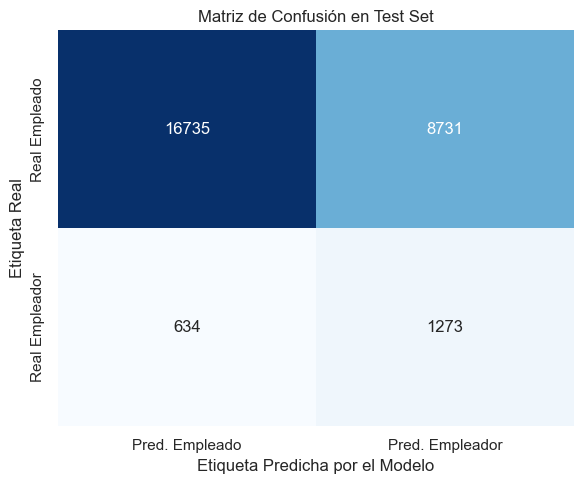

In [9]:
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred. Empleado", "Pred. Empleador"],
            yticklabels=["Real Empleado", "Real Empleador"])
plt.title("Matriz de Confusión en Test Set")
plt.ylabel("Etiqueta Real")
plt.xlabel("Etiqueta Predicha por el Modelo")
plt.tight_layout()
plt.show()

### 4.3 Métricas Detalladas de Calidad

- **Precision:** De todos los que el modelo etiquetó como "Empleador", ¿cuántos lo eran realmente?
- **Recall (Sensibilidad):** De todos los Empleadores reales, ¿cuántos logró detectar el modelo?
- **F1-Score:** Promedio armónico entre Precision y Recall.

> **Clave de Lectura:** Dado que los Empleadores (Clase 1) son la minoría (~7%), el **Recall de Clase 1** es nuestra métrica de éxito: ¿cuántos empleadores reales logra identificar el modelo?

In [10]:
print("Reporte de Clasificación (Test Set):\n")
print(classification_report(y_test, predicciones, target_names=["Empleado", "Empleador"]))

Reporte de Clasificación (Test Set):

              precision    recall  f1-score   support

    Empleado       0.96      0.66      0.78     25466
   Empleador       0.13      0.67      0.21      1907

    accuracy                           0.66     27373
   macro avg       0.55      0.66      0.50     27373
weighted avg       0.91      0.66      0.74     27373



**Lectura Crítica:** Gracias a los **pesos balanceados**, el modelo logra un Recall razonable para la clase Empleador (~67%), a costa de sacrificar Accuracy global y generar más falsos positivos. Sin esta corrección, el modelo clasificaría a prácticamente todos como empleados (Recall de Empleadores ≈ 0%) obteniendo un 93% de Accuracy que es matemáticamente inútil.

Este *trade-off* refleja una decisión de diseño: ¿Es más grave no detectar a un empleador real, o etiquetar erróneamente a un empleado como empleador? La respuesta depende del contexto de aplicación.

El F1-Score es el promedio armónico entre Precision y Recall. En escenarios desbalanceados es la métrica más honesta porque penaliza simultáneamente dos tipos de error: clasificar a alguien como empleador cuando no lo es (falso positivo), y no detectar a un empleador real (falso negativo). El Accuracy no tiene esa propiedad — con 93% de empleados, un modelo que ignore completamente a los patrones obtiene 93% de Accuracy pero F1 ≈ 0.
Por eso el F1 de Empleadores (0.21) es nuestra métrica de referencia, no el Accuracy (0.66). Un F1 bajo con Recall alto indica que el modelo detecta bien a los empleadores reales pero genera muchas falsas alarmas — trade-off esperado y aceptable dado el desbalance.

### 4.4 Análisis de Umbrales de Decisión

Por default, la regresión logística predice Clase 1 cuando la probabilidad es ≥ 0.5. En un escenario con 93% de empleados, la mayoría de las probabilidades predichas serán bajas. Al **reducir el umbral**, exigimos menos "certeza" para etiquetar como empleador, mejorando su Recall a costa de más falsos positivos:

In [11]:
umbrales = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
print("Evaluación del modelo bajo distintos Umbrales:\n")
print(f"{'Umbral':<10} | {'Acc.':<8} | {'Prec(1)':<8} | {'Rec(1)':<8} | {'Rec(0)':<8} | {'F1(1)':<8}")
print("-" * 62)

for umbral in umbrales:
    pred_u = (probabilidades >= umbral).astype(int)
    acc_u = accuracy_score(y_test, pred_u)
    prec_u = precision_score(y_test, pred_u, zero_division=0)
    rec1_u = recall_score(y_test, pred_u)
    rec0_u = recall_score(y_test, pred_u, pos_label=0)
    f1_u = f1_score(y_test, pred_u)
    print(f"{umbral:<10.2f} | {acc_u:<8.4f} | {prec_u:<8.4f} | {rec1_u:<8.4f} | {rec0_u:<8.4f} | {f1_u:<8.4f}")

Evaluación del modelo bajo distintos Umbrales:

Umbral     | Acc.     | Prec(1)  | Rec(1)   | Rec(0)   | F1(1)   
--------------------------------------------------------------
0.05       | 0.0701   | 0.0697   | 1.0000   | 0.0005   | 0.1303  
0.10       | 0.0780   | 0.0701   | 0.9974   | 0.0091   | 0.1310  
0.15       | 0.1035   | 0.0715   | 0.9906   | 0.0370   | 0.1334  
0.20       | 0.1575   | 0.0748   | 0.9754   | 0.0963   | 0.1389  
0.30       | 0.3202   | 0.0868   | 0.9198   | 0.2753   | 0.1586  
0.50       | 0.6579   | 0.1272   | 0.6675   | 0.6572   | 0.2138  


**Observaciones:**

1. Al umbral default (**0.50**), el Recall de Empleadores ya es razonable gracias a los pesos balanceados del modelo (`var_weights`). Sin esta corrección, el modelo clasificaría a casi todos como empleados y el Recall de Empleadores sería cercano a cero.
2. Al **reducir** el umbral (0.10 – 0.20), capturamos a más empleadores reales a costa de más falsos positivos.
3. La elección dependerá del objetivo: para políticas de fomento al emprendimiento (donde no detectar a un empleador real es grave), umbrales bajos son preferibles.

>**Nota**: La columna Rec(0) equivale a la especificidad: la proporción de empleados reales que el modelo identifica correctamente. Existe un trade-off directo entre especificidad y Recall de empleadores — al bajar el umbral para capturar más patrones, inevitablemente aumentan las falsas alarmas sobre empleados.

## 5. Curva ROC y Área Bajo la Curva (AUC)

La **Curva ROC** condensa la capacidad discriminativa del modelo a través de *todos* los umbrales posibles simultáneamente.

- **AUC = 0.5:** Azar.
- **AUC = 1.0:** Diagnóstico perfecto.
- **AUC > 0.7:** Capacidad discriminativa fuerte (estándar en ciencias sociales).

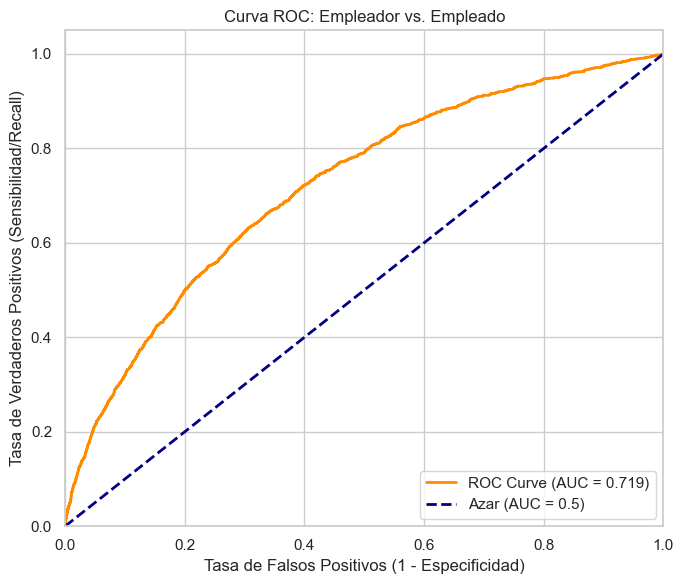

In [12]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad/Recall)")
plt.title("Curva ROC: Empleador vs. Empleado")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

El valor del **AUC** (0.719) confirma que las variables sociodemográficas y el nivel de ingresos poseen **capacidad discriminativa real** para distinguir entre empleadores y empleados. La curva se separa notablemente de la diagonal de referencia (azar), lo que indica que el modelo no está adivinando al azar sino capturando patrones reales de la estructura laboral mexicana.

## 6. Interpretación del Modelo

### 6.1 Significancia Estadística y Coeficientes

Gracias al modelo unificado (`sm.GLM` con pesos balanceados), los coeficientes, *p-values* y predicciones provienen de **la misma función de verosimilitud ponderada**. No existe discrepancia entre el modelo que interpretamos y el que genera las predicciones.

Un *p-value* < 0.05 indica que la relación no es producto del azar al 95% de confianza.

In [13]:
print(modelo_unico.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           es_empleador   No. Observations:                63869
Model:                            GLM   Df Residuals:                    63864
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39355.
Date:                Mon, 02 Mar 2026   Deviance:                       78710.
Time:                        10:17:18   Pearson chi2:                 6.42e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1427
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -7.0948      0.128    -55.592      

**Lectura de Significancia:**

Todas las variables alcanzan p-values muy inferiores a 0.05, indicando que cada predictor tiene un efecto estadísticamente significativo sobre la probabilidad de ser empleador, validando la calidad del modelo.

### 6.2 Odds Ratio: El Impacto en Términos Humanos

Los coeficientes $\beta$ del modelo logístico operan en la escala del *logit* (abstracta). Para comunicar su impacto de forma comprensible, aplicamos $e^\beta$ para obtener los **Odds Ratio**:

- **OR > 1:** La variable *aumenta* las probabilidades de ser Empleador.
- **OR < 1:** La variable *disminuye* las probabilidades.
- **Impacto %:** $(OR - 1) \times 100$

In [14]:
coeficientes = modelo_unico.params
odds_ratios = np.exp(coeficientes)

para_interprete = coeficientes.drop("const")
odds_interprete = odds_ratios.drop("const")
impacto_porcentual = (odds_interprete - 1) * 100

tabla_final = pd.DataFrame({
    "Coef. Beta": para_interprete,
    "Odds Ratio": odds_interprete,
    "Impacto % en Odds": impacto_porcentual
})
print(tabla_final.round(4))

             Coef. Beta  Odds Ratio  Impacto % en Odds
eda              0.0481      1.0493             4.9306
es_mujer        -0.5710      0.5650           -43.5027
anios_esc       -0.0221      0.9781            -2.1906
log_ingocup      0.5896      1.8033            80.3316


### 6.3 El Veredicto Econométrico

Interpretando los coeficientes del modelo (*ceteris paribus*: manteniendo todas las demás variables constantes):

---

**1. La Edad Impulsa el Rol Patronal (OR ≈ 1.049, +4.93%)**

Por cada año de edad adicional, las probabilidades de ser empleador aumentan un **+4.93%**. Esto es coherente con la teoría del ciclo vital económico: la acumulación de capital, experiencia gerencial y redes de contacto a lo largo de los años facilita la transición de subordinado a empleador. Los emprendedores requieren tiempo para acumular los recursos necesarios para dar el salto patronal.

---

**2. La Brecha de Género (OR ≈ 0.565, -43.5%)**

Al controlar por edad, educación e ingreso, ser mujer **reduce** las probabilidades de ser empleadora en un contundente **-43.5%**. La barrera se manifiesta con mayor severidad en el acceso al rol patronal que en el nivel salarial: las mujeres enfrentan obstáculos sistémicos adicionales para acceder a posiciones de liderazgo empresarial en México.

---

**3. La Educación Reduce Ligeramente las Odds Patronales (OR ≈ 0.978, -2.19%)**

Cada año adicional de escolaridad formal **disminuye** las probabilidades de ser empleador en un **-2.19%**. Este resultado, aparentemente contraintuitivo, tiene una explicación económica sólida: la educación formal canaliza a las personas hacia *carreras subordinadas especializadas* (ingeniería, medicina, derecho corporativo), donde los sueldos son competitivos y la estabilidad laboral es alta. Por otro lado, el universo de "Empleadores" en la ENOE incluye a miles de microempresarios que abandonaron tempranamente la educación formal para emprender negocios de pequeña escala (talleres, tiendas, puestos de comida).

---

**4. El Ingreso: El Predictor Dominante (OR ≈ 1.803, +80.33%)**

Si leyéramos este Odds Ratio como el resto de las variables, diríamos que "una unidad adicional aumenta las probabilidades patronales en un 80.33%". Sin embargo, dado que esta variable está transformada logarítmicamente (`log_ingocup`), una "unidad adicional" matemáticamente equivale a multiplicar el ingreso original por $e$ ($\approx 2.71$, o +171%), lo cual es un salto económico drástico y poco intuitivo.

Para un escenario en donde hay un predictor logarítmico en un modelo logístico la interpretación humana correcta es mediante elasticidades (cambios porcentuales reales). El modelo indica que:

- Un aumento del **1%** en el ingreso mensual se asocia con un aumento aproximado de **+0.59%** en los momios de ser empleador.
- Dicho de forma más impactante: si una persona logra **duplicar su ingreso mensual** (+100%), las matemáticas del modelo ($e^{0.5896 \times \ln(2)}$) dictan que sus probabilidades de operar como patrón aumentan en un **+50.5%**.

La lógica económica es directa: operar como patrón requiere capitalización inicial, capacidad de absorción de riesgo y flujo de caja, atributos que están inexorablemente ligados al nivel de ingresos formales capturados por la encuesta.


## 7. Conclusiones

### 7.1 Evaluación Técnica del Modelo

La Regresión Logística demostró ser estadísticamente robusta para este problema de clasificación. La Validación Cruzada y el Test Set arrojaron métricas idénticas (descartando sobreajuste), y el AUC de 0.719 confirmó una capacidad discriminativa real, superior al azar. Metodológicamente, el uso de **pesos balanceados** `(var_weights)` fue esencial: ante un desbalance natural del 93/7, forzó al algoritmo a "prestar atención" a la clase patronal, evitando que el modelo se convirtiera en un clasificador trivial. Finalmente, todos los predictores obtuvieron p-values < 0.05, ratificando su significancia estadística.

### 7.2 Radiografía del Mercado Laboral Mexicano

Los coeficientes del modelo permiten trazar un perfil claro del empleador mexicano: es una persona de mayor edad (la transición al rol patronal requiere años de capitalización y experiencia), con ingresos elevados (el predictor dominante, con +50.5% en odds al duplicar ingresos), y con menor escolaridad formal de lo esperado — señal de que el sistema educativo está orientado a insertar profesionistas en el empleo subordinado, no a formar emprendedores. El hallazgo más contundente, sin embargo, es la brecha de género: ser mujer reduce las probabilidades patronales en más de un 43%, controlando por todo lo demás, lo que evidencia que las barreras estructurales van mucho más allá de la brecha salarial

### Reflexión Final

La Regresión Logística demostró ser una herramienta transparente e interpretable para el análisis del mercado laboral. El hallazgo más revelador es que la **brecha de género se amplifica** al tener una oportunidad patronal mucho menor (-43.5%): las mujeres no solo ganan menos, sino que enfrentan barreras aún mayores para escalar al rol de empleadoras. Asimismo, descubrir que la educación formal "empuja" hacia el empleo subordinado (no hacia el emprendimiento) abre un debate sobre la orientación del sistema educativo mexicano hacia la empleabilidad vs. la cultura empresarial.

## Referencias

Arceo-Gomez, E., & Campos-Vázquez, R. (2014). Evolución de la brecha salarial de género en México. *El Trimestre Económico*, 81(323), 619–653.

INEGI. (2025). *Encuesta Nacional de Ocupación y Empleo (ENOE). Estructura de la base de datos* (2.ª ed.). Instituto Nacional de Estadística y Geografía.

Miranda-Sánchez, J. (2023). Emprendimiento femenino como decisión laboral en México: El caso de la frontera norte [Documento de trabajo]. ResearchGate. https://www.researchgate.net/publication/375655661

Zabludovsky, G. (2020). Mujeres y empresas: tendencias estadísticas y debates conceptuales. *Estudios Sociológicos*, 38(114), 431–464. https://doi.org/10.22201/fcpys.2448492xe.2020.240.76632

FMI. (2023). *Mexico: Selected issues — Gender gaps in the labor market* (Country Report No. 2023/357). International Monetary Fund. https://www.elibrary.imf.org/view/journals/002/2023/357/article-A001-en.xml
